# Check Padding Debug

Notebook de diagnostico para padding y `NaN` sin correr `Trainer` ni el sweep completo.

Tiene tres partes:
1. Un caso minimo de padding para ver donde quedan los `NaN`.
2. La ruta real de validacion sobre un batch con un modelo cargado o aleatorio.
3. Una reproduccion local del caso que falla: entrenamiento corto de `1` epoca con `5` timesteps y luego validacion instrumentada.


## 1. Setup

Esta version usa el contrato actual del repo: `src.config.load_config`, `src.data.build_dataloader`, `src.model.build_model` y el flujo de `src.train_module.RNADiffusionModule`.


In [1]:
from pathlib import Path
import os
import sys


def repo_root() -> Path:
    for path in [Path.cwd(), *Path.cwd().parents]:
        if (path / "src").exists() and (path / "data").exists():
            return path.resolve()
    raise RuntimeError("Run this notebook from inside the repo.")


ROOT = repo_root()
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("ROOT =", ROOT)


ROOT = /home/gkulemeyer/Documents/Repos/RNADiffusion


In [2]:
import types
from collections import OrderedDict

import matplotlib.pyplot as plt
import torch as tr
import torch.nn.functional as F

from src.config import load_config
from src.data import build_dataloader
from src.metrics import contact_f1
from src.model import build_model

tr.set_printoptions(precision=4, sci_mode=False)


In [3]:
# Defaults de depuracion
CONFIG_PATH = ROOT / "configs" / "train" / "default.yaml"
PARTITION = "valid"
BATCH_SIZE = 4
NUM_WORKERS = 0
DEVICE = tr.device("cpu")
CHECKPOINT_PATH = ROOT / "logs" / "best_model.pt"

PARTITION_PATH_OVERRIDE = None
FOLD_OVERRIDE = None
TIMESTEPS_OVERRIDE = None

SWEEP_PARTITION_PATH = ROOT / "data" / "simfolds" / "simfolds_max128" / "ArchiveII_partitions_sim60.csv"
SWEEP_TIMESTEPS = 5
SWEEP_EPOCHS = 1
SWEEP_BATCH_SIZE = 4
SWEEP_NUM_WORKERS = 0
SWEEP_FOLD = 0
SWEEP_LR = 0.001


In [4]:
def _infer_timesteps_from_state_dict(state_dict):
    for key in ("alphas", "model.alphas"):
        value = state_dict.get(key)
        if value is not None and hasattr(value, "__len__"):
            return len(value)
    return None


def _clean_state_dict_for_model(obj):
    if isinstance(obj, dict) and "state_dict" in obj:
        obj = obj["state_dict"]
    if not isinstance(obj, (dict, OrderedDict)):
        raise TypeError(f"Unsupported checkpoint object: {type(obj).__name__}")

    cleaned = OrderedDict()
    for key, value in obj.items():
        if key.startswith("model."):
            cleaned[key[len("model."):]] = value
        else:
            cleaned[key] = value
    return cleaned


def build_debug_model(config, checkpoint_path=None, device=DEVICE):
    model = build_model(config)
    source = "random_init"

    if checkpoint_path is not None and Path(checkpoint_path).exists():
        raw = tr.load(checkpoint_path, map_location="cpu")
        cleaned = _clean_state_dict_for_model(raw)
        model.load_state_dict(cleaned)
        source = str(checkpoint_path)

    model.to(device)
    model.eval()
    return model, source


def make_runtime_config(partition_path, timesteps, batch_size, num_workers, fold=0, lr=None):
    config = load_config(CONFIG_PATH)
    config["data"]["partition_path"] = str(partition_path)
    config["data"]["fold"] = fold
    config["model"]["timesteps"] = timesteps
    config["training"]["batch_size"] = batch_size
    config["training"]["num_workers"] = num_workers
    if lr is not None:
        config["training"]["lr"] = lr
    return config


def first_nonfinite_parameter_name(model):
    for name, param in model.named_parameters():
        if not tr.isfinite(param.detach()).all():
            return name
    return None


def find_padded_sample_index(lengths, max_len, ratio=0.9):
    for idx, length in enumerate(lengths):
        if length < ratio * max_len:
            return idx
    return 0


config = load_config(CONFIG_PATH)
if PARTITION_PATH_OVERRIDE is not None:
    config["data"]["partition_path"] = str(PARTITION_PATH_OVERRIDE)
if FOLD_OVERRIDE is not None:
    config["data"]["fold"] = FOLD_OVERRIDE
if TIMESTEPS_OVERRIDE is not None:
    config["model"]["timesteps"] = TIMESTEPS_OVERRIDE

if CHECKPOINT_PATH.exists():
    loaded_state_dict = _clean_state_dict_for_model(tr.load(CHECKPOINT_PATH, map_location="cpu"))
    inferred_timesteps = _infer_timesteps_from_state_dict(loaded_state_dict)
    if inferred_timesteps is not None:
        config["model"]["timesteps"] = inferred_timesteps
else:
    loaded_state_dict = None
    inferred_timesteps = None

config["training"]["batch_size"] = BATCH_SIZE
config["training"]["num_workers"] = NUM_WORKERS
model, model_source = build_debug_model(
    config,
    CHECKPOINT_PATH if CHECKPOINT_PATH.exists() else None,
    DEVICE,
)

print("partition =", PARTITION)
print("batch_size =", config["training"]["batch_size"])
print("num_workers =", config["training"]["num_workers"])
print("timesteps =", config["model"]["timesteps"])
print("checkpoint =", model_source)


partition = valid
batch_size = 4
num_workers = 0
timesteps = 5
checkpoint = random_init


In [5]:
loader = build_dataloader(config, partition=PARTITION, batch_size=BATCH_SIZE, shuffle=False)
batch = next(iter(loader))
print("batch keys:", sorted(batch.keys()))
print("lengths:", batch["length"])
print("conditioning shape:", tuple(batch["conditioning"].shape))
print("contact_oh shape:", tuple(batch["contact_oh"].shape))
print("mask shape:", tuple(batch["mask"].shape))

idx = find_padded_sample_index(batch["length"], batch["contact_oh"].shape[-1])
seq_len = batch["length"][idx]
max_len = batch["contact_oh"].shape[-1]

x0_real = batch["contact_oh"][idx:idx + 1].float().to(DEVICE)
cond = batch["conditioning"][idx:idx + 1].float().to(DEVICE)
mask_real = batch["mask"][idx:idx + 1].to(DEVICE)
mask2d = mask_real[0, 0]
fill = tr.tensor([1.0, 0.0], dtype=x0_real.dtype, device=x0_real.device).view(1, 2, 1, 1)

print("sample idx =", idx)
print("seq_len =", seq_len)
print("max_len =", max_len)
print("valid pixel contact =", x0_real[0, :, 0, 0])
print("padded pixel contact =", x0_real[0, :, seq_len, seq_len])
print("padded pixel conditioning =", cond[0, :4, seq_len, seq_len])
print("mask padded pixel =", mask2d[seq_len, seq_len])


batch keys: ['conditioning', 'contact', 'contact_oh', 'embedding', 'id', 'length', 'mask', 'sequence']
lengths: [112, 120, 85, 117]
conditioning shape: (4, 16, 120, 120)
contact_oh shape: (4, 2, 120, 120)
mask shape: (4, 1, 120, 120)
sample idx = 2
seq_len = 85
max_len = 120
valid pixel contact = tensor([1., 0.])
padded pixel contact = tensor([nan, nan])
padded pixel conditioning = tensor([nan, nan, nan, nan])
mask padded pixel = tensor(False)


## 2. Helpers de inspeccion

Estas funciones no cambian el repo. Solo resumen tensores, guardan observaciones y permiten instrumentar temporalmente un modelo para ver donde aparece el primer no-finito en zona valida.


In [6]:
DEBUG_RUNS = {}
CURRENT_MASK = None
CURRENT_BATCH_INDEX = None


def ensure_debug_run(run_name):
    return DEBUG_RUNS.setdefault(run_name, {"observations": []})


def mask_for_tensor(mask, tensor):
    if mask is None:
        return None
    mask_cpu = mask.detach().cpu().bool()
    tensor_cpu = tensor.detach().cpu()

    if mask_cpu.ndim == 4 and tensor_cpu.ndim == 3 and mask_cpu.shape[1] == 1:
        mask_cpu = mask_cpu.squeeze(1)
    elif mask_cpu.ndim == 3 and tensor_cpu.ndim == 4:
        mask_cpu = mask_cpu.unsqueeze(1)

    if mask_cpu.ndim != tensor_cpu.ndim:
        raise ValueError(
            f"Cannot align mask shape {tuple(mask_cpu.shape)} with tensor shape {tuple(tensor_cpu.shape)}"
        )
    if mask_cpu.shape != tensor_cpu.shape:
        mask_cpu = mask_cpu.expand(tensor_cpu.shape)
    return mask_cpu


def record_observation(run_name, name, tensor, mask=None, extra=None):
    run = ensure_debug_run(run_name)
    tensor_cpu = tensor.detach().cpu()
    finite = tr.isfinite(tensor_cpu)
    item = {
        "run_name": run_name,
        "name": name,
        "shape": tuple(tensor_cpu.shape),
        "finite_all": bool(finite.all().item()),
        "nan_count": int(tr.isnan(tensor_cpu).sum().item()),
        "inf_count": int(tr.isinf(tensor_cpu).sum().item()),
        "valid_finite_all": None,
        "valid_nan_count": None,
        "extra": extra or {},
    }

    if mask is not None:
        aligned_mask = mask_for_tensor(mask, tensor)
        valid_values = tensor_cpu[aligned_mask]
        valid_finite = tr.isfinite(valid_values)
        item["valid_finite_all"] = bool(valid_finite.all().item()) if valid_values.numel() else True
        item["valid_nan_count"] = int(tr.isnan(valid_values).sum().item()) if valid_values.numel() else 0
        finite_valid_values = valid_values[tr.isfinite(valid_values)]
        item["valid_min"] = float(finite_valid_values.min().item()) if finite_valid_values.numel() else None
        item["valid_max"] = float(finite_valid_values.max().item()) if finite_valid_values.numel() else None
    else:
        finite_values = tensor_cpu[finite]
        item["valid_min"] = float(finite_values.min().item()) if finite_values.numel() else None
        item["valid_max"] = float(finite_values.max().item()) if finite_values.numel() else None

    run["observations"].append(item)
    return item


def first_nonfinite_indices(tensor, mask=None, limit=5):
    tensor_cpu = tensor.detach().cpu()
    bad = ~tr.isfinite(tensor_cpu)
    if mask is not None:
        bad = bad & mask_for_tensor(mask, tensor)
    coords = bad.nonzero(as_tuple=False)
    return [tuple(int(v) for v in row.tolist()) for row in coords[:limit]]


def tensor_report(run_name, name, tensor, mask=None):
    report = record_observation(run_name, name, tensor, mask=mask)
    print(
        f"[{run_name}] {name}: shape={report['shape']} finite_all={report['finite_all']} "
        f"nan={report['nan_count']} inf={report['inf_count']} "
        f"valid_finite_all={report['valid_finite_all']} valid_nan={report['valid_nan_count']} "
        f"valid_min={report['valid_min']} valid_max={report['valid_max']}"
    )
    if report["valid_finite_all"] is False:
        print("  first valid non-finite indices:", first_nonfinite_indices(tensor, mask=mask))
    return report


def install_debug_wrappers(debug_model, run_name):
    originals = {
        "predict_start": debug_model.predict_start,
        "q_posterior": debug_model.q_posterior,
        "pred_p_xt_1_from_xt": debug_model.pred_p_xt_1_from_xt,
        "sample_from_probs": debug_model.sample_from_probs,
    }

    def log_event(stage, tensor, mask=None, t=None):
        event = record_observation(
            run_name,
            stage,
            tensor,
            mask=mask,
            extra={
                "t": None if t is None else [int(v) for v in tr.as_tensor(t).detach().cpu().flatten().tolist()],
                "batch_idx": CURRENT_BATCH_INDEX,
            },
        )
        if event["valid_finite_all"] is False:
            print(
                f"[DEBUG][{run_name}] {stage}: finite_all={event['finite_all']} nan={event['nan_count']} "
                f"inf={event['inf_count']} valid_finite_all={event['valid_finite_all']} "
                f"valid_nan={event['valid_nan_count']} batch_idx={CURRENT_BATCH_INDEX} t={event['extra']['t']}"
            )
            print("    first valid non-finite indices:", first_nonfinite_indices(tensor, mask=mask))
        return event

    def predict_start_debug(self, xt, t, condition, mask=None, return_logits=False):
        logits = originals["predict_start"](xt, t, condition, mask=mask, return_logits=True)
        debug_mask = mask if mask is not None else None
        log_event("predict_start/logits", logits, mask=debug_mask, t=t)
        if return_logits:
            return logits
        probs = F.softmax(logits, dim=1)
        log_event("predict_start/probs", probs, mask=debug_mask, t=t)
        return probs

    def q_posterior_debug(self, x0, xt, t):
        out = originals["q_posterior"](x0, xt, t)
        debug_mask = CURRENT_MASK if CURRENT_MASK is not None else None
        log_event("q_posterior", out, mask=debug_mask, t=t)
        return out

    def pred_p_xt_1_from_xt_debug(self, xt, t, condition, mask=None):
        out = originals["pred_p_xt_1_from_xt"](xt, t, condition, mask=mask)
        debug_mask = mask if mask is not None else None
        log_event("pred_p_xt_1_from_xt", out, mask=debug_mask, t=t)
        return out

    def sample_from_probs_debug(self, probs, mask=None):
        debug_mask = mask if mask is not None else None
        log_event("sample_from_probs/input", probs, mask=debug_mask)
        return originals["sample_from_probs"](probs, mask=mask)

    debug_model.predict_start = types.MethodType(predict_start_debug, debug_model)
    debug_model.q_posterior = types.MethodType(q_posterior_debug, debug_model)
    debug_model.pred_p_xt_1_from_xt = types.MethodType(pred_p_xt_1_from_xt_debug, debug_model)
    debug_model.sample_from_probs = types.MethodType(sample_from_probs_debug, debug_model)
    return originals


def run_validation_probe(debug_model, batch, run_name, batch_idx=0):
    global CURRENT_MASK, CURRENT_BATCH_INDEX
    CURRENT_BATCH_INDEX = batch_idx

    condition_full = batch["conditioning"].float().to(DEVICE)
    target_full = batch["contact_oh"].float().to(DEVICE)
    mask_full = batch["mask"].to(DEVICE)
    lengths_full = batch["length"]
    CURRENT_MASK = mask_full

    tensor_report(run_name, "batch/conditioning", condition_full, mask=mask_full)
    tensor_report(run_name, "batch/contact_oh", target_full, mask=mask_full)
    tensor_report(run_name, "batch/mask", mask_full)

    loss_error = None
    sample_error = None
    loss_value = None
    predictions = None
    f1_scores = None

    try:
        loss_value = debug_model.forward_all_timesteps(target_full, condition_full, mask=mask_full)
        print(f"[{run_name}] loss =", float(loss_value))
    except Exception as exc:
        loss_error = exc
        print(f"[{run_name}] loss path failed:", type(exc).__name__, exc)

    try:
        predictions = debug_model.sample(condition_full, mask=mask_full)
        f1_scores = contact_f1(predictions, target_full, lengths=lengths_full, reduce=False)
        print(f"[{run_name}] predictions shape =", tuple(predictions.shape))
        print(f"[{run_name}] f1 =", f1_scores.tolist())
    except Exception as exc:
        sample_error = exc
        print(f"[{run_name}] sampling path failed:", type(exc).__name__, exc)

    return {
        "loss": loss_value,
        "loss_error": loss_error,
        "sample_error": sample_error,
        "predictions": predictions,
        "f1": f1_scores,
        "batch_idx": batch_idx,
    }


def scan_validation_loader(debug_model, loader, run_name, max_batches=None):
    results = []
    for batch_idx, batch in enumerate(loader):
        print(f"--- {run_name}: validation batch {batch_idx} ---")
        result = run_validation_probe(debug_model, batch, run_name, batch_idx=batch_idx)
        results.append(result)
        if result["loss_error"] is not None or result["sample_error"] is not None:
            print(f"[{run_name}] stopping scan at batch {batch_idx} because the failure was reproduced.")
            break
        if max_batches is not None and batch_idx + 1 >= max_batches:
            break
    return results


def summarize_run(run_name, model_source="random_init", results=None):
    observations = DEBUG_RUNS.get(run_name, {}).get("observations", [])
    first_any = next((obs for obs in observations if not obs["finite_all"]), None)
    first_valid = next((obs for obs in observations if obs["valid_finite_all"] is False), None)
    loss_error = None
    sample_error = None
    failing_batch = None
    if results:
        for item in results:
            if item["loss_error"] is not None or item["sample_error"] is not None:
                loss_error = item["loss_error"]
                sample_error = item["sample_error"]
                failing_batch = item["batch_idx"]
                break

    print("=== SUMMARY:", run_name, "===")
    print("model source:", model_source)
    print("failing batch:", failing_batch)
    print("loss path status:", "ok" if loss_error is None else f"failed ({type(loss_error).__name__})")
    print("sampling path status:", "ok" if sample_error is None else f"failed ({type(sample_error).__name__})")

    if first_any is None:
        print("first any non-finite tensor: none detected")
    else:
        print("first any non-finite tensor:", first_any["name"])
        print("  valid_finite_all:", first_any["valid_finite_all"])
        print("  extra:", first_any["extra"])

    if first_valid is None:
        print("first valid-zone non-finite tensor: none detected")
    else:
        print("first valid-zone non-finite tensor:", first_valid["name"])
        print("  shape:", first_valid["shape"])
        print("  nan_count:", first_valid["nan_count"])
        print("  inf_count:", first_valid["inf_count"])
        print("  extra:", first_valid["extra"])

    return {
        "run_name": run_name,
        "first_any_nonfinite": first_any,
        "first_valid_nonfinite": first_valid,
        "loss_error": loss_error,
        "sample_error": sample_error,
        "failing_batch": failing_batch,
    }


## 3. Parte A: caso minimo de padding

Inspeccionamos primero un batch real con padding y luego el pipeline corto `q_pred -> q_sample -> q_posterior`.


[base_model] contact_oh/sample: shape=(1, 2, 120, 120) finite_all=False nan=14350 inf=0 valid_finite_all=True valid_nan=0 valid_min=0.0 valid_max=1.0
[base_model] conditioning/sample: shape=(1, 16, 120, 120) finite_all=False nan=114800 inf=0 valid_finite_all=True valid_nan=0 valid_min=0.0 valid_max=1.0
[base_model] mask/sample: shape=(1, 1, 120, 120) finite_all=True nan=0 inf=0 valid_finite_all=None valid_nan=None valid_min=0.0 valid_max=1.0


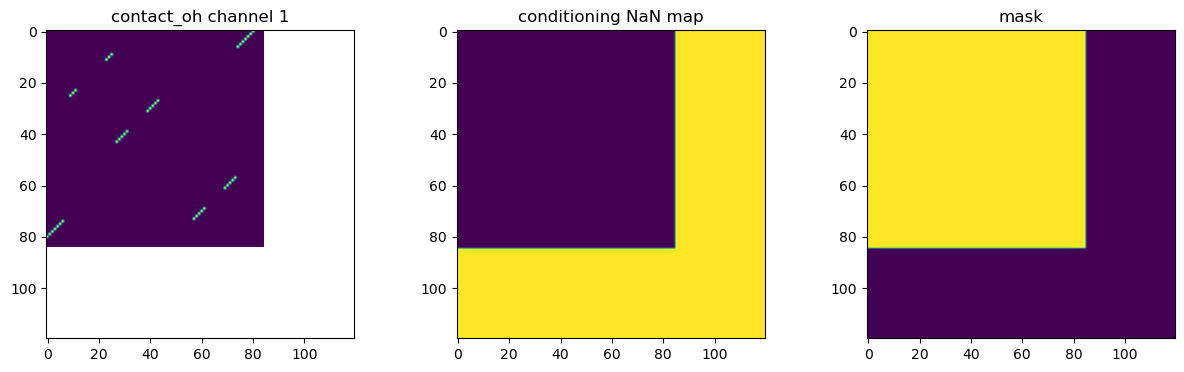

In [7]:
BASE_RUN = "base_model"

tensor_report(BASE_RUN, "contact_oh/sample", x0_real, mask=mask_real)
tensor_report(BASE_RUN, "conditioning/sample", cond, mask=mask_real)
tensor_report(BASE_RUN, "mask/sample", mask_real)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(x0_real[0, 1].detach().cpu())
axes[0].set_title("contact_oh channel 1")
axes[1].imshow(tr.isnan(cond[0, 0]).detach().cpu())
axes[1].set_title("conditioning NaN map")
axes[2].imshow(mask2d.detach().cpu())
axes[2].set_title("mask")
plt.show()


In [8]:
CURRENT_MASK = mask_real
time0 = tr.tensor([0], device=DEVICE)
time_mid = tr.tensor([model.time_steps // 2], device=DEVICE)

q0 = model.q_pred(x0_real, time0)
q_mid = model.q_pred(x0_real, time_mid)
xt_mid = model.q_sample(x0_real, time_mid, gumbel=True)
post_mid = model.q_posterior(x0_real, xt_mid, time_mid)

print("q0 padded pixel:", q0[0, :, seq_len, seq_len])
print("q_mid padded pixel:", q_mid[0, :, seq_len, seq_len])
print("xt_mid padded pixel:", xt_mid[0, :, seq_len, seq_len])
print("post_mid padded pixel:", post_mid[0, :, seq_len, seq_len])

tensor_report(BASE_RUN, "q_pred(t=0)", q0, mask=mask_real)
tensor_report(BASE_RUN, "q_pred(t=mid)", q_mid, mask=mask_real)
tensor_report(BASE_RUN, "q_sample(t=mid)", xt_mid, mask=mask_real)
tensor_report(BASE_RUN, "q_posterior(t=mid)", post_mid, mask=mask_real)
print("first non-finite q_mid valid indices:", first_nonfinite_indices(q_mid, mask=mask_real))
print("first non-finite xt_mid valid indices:", first_nonfinite_indices(xt_mid, mask=mask_real))
print("first non-finite post_mid valid indices:", first_nonfinite_indices(post_mid, mask=mask_real))


q0 padded pixel: tensor([nan, nan])
q_mid padded pixel: tensor([nan, nan])
xt_mid padded pixel: tensor([nan, nan])
post_mid padded pixel: tensor([nan, nan])
[base_model] q_pred(t=0): shape=(1, 2, 120, 120) finite_all=False nan=14350 inf=0 valid_finite_all=True valid_nan=0 valid_min=5.960464477539063e-08 valid_max=0.9999999403953552
[base_model] q_pred(t=mid): shape=(1, 2, 120, 120) finite_all=False nan=14350 inf=0 valid_finite_all=True valid_nan=0 valid_min=0.31236231327056885 valid_max=0.6876376867294312
[base_model] q_sample(t=mid): shape=(1, 2, 120, 120) finite_all=False nan=14350 inf=0 valid_finite_all=True valid_nan=0 valid_min=7.361372990999371e-05 valid_max=0.9999263286590576
[base_model] q_posterior(t=mid): shape=(1, 2, 120, 120) finite_all=False nan=14350 inf=0 valid_finite_all=True valid_nan=0 valid_min=0.04915345087647438 valid_max=0.9508465528488159
first non-finite q_mid valid indices: []
first non-finite xt_mid valid indices: []
first non-finite post_mid valid indices: []

In [9]:
x0_fill = tr.where(mask_real.bool(), x0_real, fill)
xt_fill = tr.where(mask_real.bool(), xt_mid, fill)
q_fill = model.q_pred(x0_fill, time_mid)
post_fill = model.q_posterior(x0_fill, xt_fill, time_mid)

print("x0_fill padded pixel:", x0_fill[0, :, seq_len, seq_len])
print("xt_fill padded pixel:", xt_fill[0, :, seq_len, seq_len])
print("post_fill padded pixel:", post_fill[0, :, seq_len, seq_len])

tensor_report(BASE_RUN, "q_pred(filled)", q_fill, mask=mask_real)
tensor_report(BASE_RUN, "q_posterior(filled)", post_fill, mask=mask_real)


x0_fill padded pixel: tensor([1., 0.])
xt_fill padded pixel: tensor([1., 0.])
post_fill padded pixel: tensor([0.9509, 0.0491])
[base_model] q_pred(filled): shape=(1, 2, 120, 120) finite_all=True nan=0 inf=0 valid_finite_all=True valid_nan=0 valid_min=0.31236231327056885 valid_max=0.6876376867294312
[base_model] q_posterior(filled): shape=(1, 2, 120, 120) finite_all=True nan=0 inf=0 valid_finite_all=True valid_nan=0 valid_min=0.04915345087647438 valid_max=0.9508465528488159


{'run_name': 'base_model',
 'name': 'q_posterior(filled)',
 'shape': (1, 2, 120, 120),
 'finite_all': True,
 'nan_count': 0,
 'inf_count': 0,
 'valid_finite_all': True,
 'valid_nan_count': 0,
 'extra': {},
 'valid_min': 0.04915345087647438,
 'valid_max': 0.9508465528488159}

## 4. Parte B: flujo real de validacion sobre un batch

Replicamos localmente lo que hace `validation_step` con el modelo cargado o aleatorio, sin `Trainer`.


In [10]:
install_debug_wrappers(model, BASE_RUN)
base_results = scan_validation_loader(model, loader, BASE_RUN, max_batches=1)
base_summary = summarize_run(BASE_RUN, model_source=model_source, results=base_results)


--- base_model: validation batch 0 ---
[base_model] batch/conditioning: shape=(4, 16, 120, 120) finite_all=False nan=155872 inf=0 valid_finite_all=True valid_nan=0 valid_min=0.0 valid_max=1.0
[base_model] batch/contact_oh: shape=(4, 2, 120, 120) finite_all=False nan=19484 inf=0 valid_finite_all=True valid_nan=0 valid_min=0.0 valid_max=1.0
[base_model] batch/mask: shape=(4, 1, 120, 120) finite_all=True nan=0 inf=0 valid_finite_all=None valid_nan=None valid_min=0.0 valid_max=1.0
[base_model] loss = 0.9803469777107239
[base_model] predictions shape = (4, 120, 120)
[base_model] f1 = [0.006808510638297872, 0.008125952260030472, 0.009685230024213074, 0.008447729672650475]
=== SUMMARY: base_model ===
model source: random_init
failing batch: None
loss path status: ok
sampling path status: ok
first any non-finite tensor: contact_oh/sample
  valid_finite_all: True
  extra: {}
first valid-zone non-finite tensor: none detected


## 5. Parte C: reproducir el fallo del sweep en el notebook

Aqui entrenamos un modelo nuevo durante `1` epoca con `5` timesteps usando la particion `sim60`, y luego recorremos la validacion hasta reproducir el fallo.


In [11]:
assert SWEEP_PARTITION_PATH.exists(), f"Partition path not found: {SWEEP_PARTITION_PATH}"

sweep_config = make_runtime_config(
    partition_path=SWEEP_PARTITION_PATH,
    timesteps=SWEEP_TIMESTEPS,
    batch_size=SWEEP_BATCH_SIZE,
    num_workers=SWEEP_NUM_WORKERS,
    fold=SWEEP_FOLD,
    lr=SWEEP_LR,
)

print("sweep partition path =", sweep_config["data"]["partition_path"])
print("sweep timesteps =", sweep_config["model"]["timesteps"])
print("sweep batch_size =", sweep_config["training"]["batch_size"])
print("sweep num_workers =", sweep_config["training"]["num_workers"])
print("sweep lr =", sweep_config["training"]["lr"])

tr.manual_seed(sweep_config["experiment"]["seed"])
train_loader = build_dataloader(sweep_config, partition="train", batch_size=SWEEP_BATCH_SIZE, shuffle=False)
valid_loader = build_dataloader(sweep_config, partition="valid", batch_size=SWEEP_BATCH_SIZE, shuffle=False)

trained_model = build_model(sweep_config).to(DEVICE)
trained_model.train()
optimizer = tr.optim.Adam(trained_model.parameters(), lr=sweep_config["training"]["lr"])

train_losses = []
training_error = None
nonfinite_param_name = None

for epoch in range(SWEEP_EPOCHS):
    print(f"--- training epoch {epoch} ---")
    for batch_idx, train_batch in enumerate(train_loader):
        optimizer.zero_grad(set_to_none=True)
        train_contact = train_batch["contact_oh"].float().to(DEVICE)
        train_condition = train_batch["conditioning"].float().to(DEVICE)
        train_mask = train_batch["mask"].to(DEVICE)

        loss = trained_model.forward_all_timesteps(train_contact, train_condition, mask=train_mask)
        train_losses.append(float(loss.detach().cpu()))
        if not tr.isfinite(loss):
            training_error = RuntimeError(f"non-finite training loss at epoch={epoch} batch={batch_idx}")
            print(training_error)
            break

        loss.backward()
        optimizer.step()

        nonfinite_param_name = first_nonfinite_parameter_name(trained_model)
        if nonfinite_param_name is not None:
            training_error = RuntimeError(f"non-finite parameter after optimizer step: {nonfinite_param_name}")
            print(training_error)
            break

        if batch_idx in (0, 1, 2, len(train_loader) - 1):
            print(f"epoch={epoch} batch={batch_idx} loss={train_losses[-1]:.6f}")
    if training_error is not None:
        break

trained_model.eval()
print("train batches seen =", len(train_losses))
print("first 3 train losses =", train_losses[:3])
print("last train loss =", train_losses[-1] if train_losses else None)
print("nonfinite parameter =", nonfinite_param_name)
print("training error =", training_error)


sweep partition path = /home/gkulemeyer/Documents/Repos/RNADiffusion/data/simfolds/simfolds_max128/ArchiveII_partitions_sim60.csv
sweep timesteps = 5
sweep batch_size = 4
sweep num_workers = 0
sweep lr = 0.001
--- training epoch 0 ---
non-finite parameter after optimizer step: diffuser.time_mlp.1.weight
train batches seen = 1
first 3 train losses = [0.7521510720252991]
last train loss = 0.7521510720252991
nonfinite parameter = diffuser.time_mlp.1.weight
training error = non-finite parameter after optimizer step: diffuser.time_mlp.1.weight


In [12]:
TRAINED_RUN = "trained_sim60_t5_e1"
install_debug_wrappers(trained_model, TRAINED_RUN)
trained_results = scan_validation_loader(trained_model, valid_loader, TRAINED_RUN, max_batches=None)
trained_summary = summarize_run(TRAINED_RUN, model_source="manual_train(sim60, t=5, e=1)", results=trained_results)


--- trained_sim60_t5_e1: validation batch 0 ---
[trained_sim60_t5_e1] batch/conditioning: shape=(4, 16, 108, 108) finite_all=False nan=243984 inf=0 valid_finite_all=True valid_nan=0 valid_min=0.0 valid_max=1.0
[trained_sim60_t5_e1] batch/contact_oh: shape=(4, 2, 108, 108) finite_all=False nan=30498 inf=0 valid_finite_all=True valid_nan=0 valid_min=0.0 valid_max=1.0
[trained_sim60_t5_e1] batch/mask: shape=(4, 1, 108, 108) finite_all=True nan=0 inf=0 valid_finite_all=None valid_nan=None valid_min=0.0 valid_max=1.0
[DEBUG][trained_sim60_t5_e1] predict_start/logits: finite_all=False nan=93312 inf=0 valid_finite_all=False valid_nan=62814 batch_idx=0 t=[0, 0, 0, 0]
    first valid non-finite indices: [(0, 0, 0, 0), (0, 0, 0, 1), (0, 0, 0, 2), (0, 0, 0, 3), (0, 0, 0, 4)]
[DEBUG][trained_sim60_t5_e1] predict_start/probs: finite_all=False nan=93312 inf=0 valid_finite_all=False valid_nan=62814 batch_idx=0 t=[0, 0, 0, 0]
    first valid non-finite indices: [(0, 0, 0, 0), (0, 0, 0, 1), (0, 0, 0, 2

## 6. Sintesis automatica

Esta celda resume el caso estable y el caso reproducido despues del entrenamiento corto.


In [13]:
print("=== FINAL TAKEAWAY ===")
print("base summary:")
print(base_summary)
print()
print("trained summary:")
print(trained_summary)
print()

if trained_summary["sample_error"] is not None:
    print("El error se reproduce en validacion durante la ruta de sampling.")
    if trained_summary["first_valid_nonfinite"] is not None:
        first_valid = trained_summary["first_valid_nonfinite"]
        print("Primer tensor con no-finitos en zona valida:", first_valid["name"])
        print("Batch de validacion:", trained_summary["failing_batch"])
        print("Extra:", first_valid["extra"])
        if first_valid["name"] == "predict_start/logits":
            print("Punto exacto: el modelo ya devuelve logits no finitos antes del softmax.")
        elif first_valid["name"] == "predict_start/probs":
            print("Punto exacto: el softmax produce probabilidades no finitas.")
        elif first_valid["name"] == "pred_p_xt_1_from_xt":
            print("Punto exacto: la combinacion con q_posterior rompe despues de predecir x0.")
        elif first_valid["name"] == "sample_from_probs/input":
            print("Punto exacto: sample_from_probs recibe probabilidades invalidas antes de llamar a multinomial.")
        else:
            print("Punto exacto: el primer tensor no finito aparece en la etapa indicada arriba.")
    else:
        print("No se detecto un tensor invalido en zona valida antes de la excepcion; revisar la observacion inmediatamente anterior.")
elif trained_summary["loss_error"] is not None:
    print("El error se reproduce antes del sampling, en la ruta de loss.")
else:
    print("El notebook no reprodujo el error en esta ejecucion. Revisa seed, particion o cantidad de batches recorridos.")


=== FINAL TAKEAWAY ===
base summary:
{'run_name': 'base_model', 'first_any_nonfinite': {'run_name': 'base_model', 'name': 'contact_oh/sample', 'shape': (1, 2, 120, 120), 'finite_all': False, 'nan_count': 14350, 'inf_count': 0, 'valid_finite_all': True, 'valid_nan_count': 0, 'extra': {}, 'valid_min': 0.0, 'valid_max': 1.0}, 'first_valid_nonfinite': None, 'loss_error': None, 'sample_error': None, 'failing_batch': None}

trained summary:
{'run_name': 'trained_sim60_t5_e1', 'first_any_nonfinite': {'run_name': 'trained_sim60_t5_e1', 'name': 'batch/conditioning', 'shape': (4, 16, 108, 108), 'finite_all': False, 'nan_count': 243984, 'inf_count': 0, 'valid_finite_all': True, 'valid_nan_count': 0, 'extra': {}, 'valid_min': 0.0, 'valid_max': 1.0}, 'first_valid_nonfinite': {'run_name': 'trained_sim60_t5_e1', 'name': 'predict_start/logits', 'shape': (4, 2, 108, 108), 'finite_all': False, 'nan_count': 93312, 'inf_count': 0, 'valid_finite_all': False, 'valid_nan_count': 62814, 'extra': {'t': [0, 0, 